# Chromophore-anchored peak-guided design — multi-scaffold tasks

Sibling of `guided_design_peak_chromophore_avgfp.ipynb`, refocused on a fixed set of **scaffold → target**
guided-generation tasks with a **chromophore-anchored edit window** (surrogate guides on `(ex_max, em_max)`,
oracle judges). Uses the dual models retrained on the current split (DATASIG 5849fbf0).

**Design tasks (scaffold → targets):**
- **DsRed** → ZsGreen, ZsYellow1, LSSmOrange, mRuby
- **avGFP** → mAmetrine, Sumire, sREACh2, Sirius
- **eqFP578** → LSS-mKate1, LSS-mKate2, mBeRFP

**Edit window (per scaffold):** locate the chromophore X-[Tyr]-Gly tripeptide, then edit only within
**10 residues before (backbone) + the chromophore tripeptide + 10 residues after (backbone)**.

**Design settings (per request):**
- **λ = 25** (constant, no ramp) and **temperature = 10** (stochastic sampling) for every iteration.
- All neural nets (ESM-2, surrogate, oracle) are pinned to **MPS**.
- **3 iterations** per task; each iteration edits the chromophore then the backbone flank, sharing λ.
- Chromophore positions **1 = X, 2 = Tyr, 3 = Gly**. **Position 2 is constrained to aromatic residues
  {Y, W, H, F}** (color-shift chemistry allowed; ring deletion blocked). **Position 3 (Gly) is fixed** —
  never edited (structurally required for cyclization). Position 1 (X) and the ±10 backbone flanks are free.

Detected chromophores: avGFP **S65-Y66-G67**, DsRed **Q66-Y67-G68**, eqFP578 **M63-Y64-G65**.

## 0. Setup + data + dual labels

In [1]:
import csv, os, numpy as np, torch
import peak_models as pm
try:
    import arcadia_pycolor as apc; apc.mpl.setup(); HAVE_APC=True
except Exception:
    HAVE_APC=False
try:
    import matplotlib.pyplot as plt; HAVE_PLT=True
except Exception:
    HAVE_PLT=False
class _C:
    def __getattr__(self, k): return getattr(apc, k) if HAVE_APC else {"aegean":"#2b6c8f","amber":"#f6a200","rose":"#c5474b","seaweed":"#3b8a6e","gray":"#888888","wish":"#5088c5","aster":"#7a5ea8"}.get(k,"#333333")
apc_c=_C()

CUR="../dataset_pipeline/data/peak/curated"   # curated data + dual split (new pipeline; matches dual models)
assert getattr(torch.backends,"mps",None) and torch.backends.mps.is_available(), "MPS required but not available"
dev=torch.device("mps")   # force ALL neural nets (ESM-2, surrogate, oracle) onto MPS
rows=list(csv.DictReader(open(os.path.join(CUR,"peaks_assignments.csv")))); N=len(rows)
peaks=np.load(os.path.join(CUR,"peaks.npy")).astype(np.float32); EXM=peaks[:,0]; EMM=peaks[:,1]
seqs=[None]*N; h=None
for line in open(os.path.join(CUR,"sequences.fasta")):
    line=line.strip()
    if line.startswith(">"): h=int(line[1:].split("|")[0])
    elif line: seqs[h]=line
dual=list(csv.DictReader(open(os.path.join(CUR,"dual_splits.csv"))))
Srole=np.array([d["surrogate_role"] for d in dual]); Orole=np.array([d["oracle_role"] for d in dual])
print("device",dev,"| N",N,"| surrogate roles",{b:int((Srole==b).sum()) for b in('train','val','test')})

device mps | N 758 | surrogate roles {'train': 528, 'val': 112, 'test': 118}


## 1. Load dual models (+ peak scalers) and wire peak predictors

In [2]:
ss=np.load(os.path.join("trained_models","dual_surrogate_scaler.npz")); os_=np.load(os.path.join("trained_models","dual_oracle_scaler.npz"))
surrogate_net, s_meta = pm.load_wrapped(os.path.join("trained_models","dual_surrogate_net.pt"), ss["mean"], ss["std"], dev)
oracle_net,    o_meta = pm.load_wrapped(os.path.join("trained_models","dual_oracle_net.pt"),    os_["mean"], os_["std"], dev)
print(f"surrogate: {s_meta['sid']} ({s_meta['arch']}) | val MAE {s_meta['metrics']['val']['mae']:.1f} nm")
print(f"oracle:    {o_meta['sid']} ({o_meta['arch']}) | val MAE {o_meta['metrics']['val']['mae']:.1f} nm")

g_peaks      = pm.peaks_fn(surrogate_net, dev)    # GUIDANCE: seqs -> (B,2) nm (ex_max, em_max)
oracle_peaks = pm.peaks_fn(oracle_net,    dev)    # EVALUATION

esm_model, alphabet, bc = pm.get_esm(dev)
AA_MASK = torch.zeros(len(alphabet.all_toks), dtype=torch.bool)
for a in "ACDEFGHIKLMNPQRSTVWY": AA_MASK[alphabet.get_idx(a)] = True
AA_MASK = AA_MASK.to(dev)
SPECIAL = {alphabet.cls_idx, alphabet.eos_idx, alphabet.padding_idx, alphabet.mask_idx}

def peak_err_vec(P, target):
    """Mean absolute peak error (nm) between predicted peaks P (B,2) and a target (2,). Lower = better."""
    return 0.5*((P[:,0]-target[0]).abs() + (P[:,1]-target[1]).abs())

# --- verify every network is actually on MPS ---
for _n,_net in [("ESM-2",esm_model),("surrogate",surrogate_net),("oracle",oracle_net)]:
    _d=next(_net.parameters()).device
    assert _d.type=="mps", f"{_n} on {_d}, expected mps"
print("all networks on MPS:", next(esm_model.parameters()).device, "| surrogate", next(surrogate_net.parameters()).device, "| oracle", next(oracle_net.parameters()).device)

surrogate: cnn-max-d1 (cnn) | val MAE 13.5 nm
oracle:    cnn-concatstd-d1 (cnn) | val MAE 14.5 nm


all networks on MPS: mps:0 | surrogate mps:0 | oracle mps:0


## 2. Pseudo-perplexity (naturalness metric used during design)

In [3]:
@torch.no_grad()
def pseudo_perplexity(seq, batch_size=32):
    # mask each residue in its own row, gather the true-token logprob in one shot per batch.
    # (avoid per-element float(lp[r,p,..]) indexing -> each call forces a GPU->CPU sync on MPS)
    _,_,base=bc([("s",seq.strip().upper())]); base=base[0].to(dev)
    res=[i for i,t in enumerate(base.tolist()) if t not in SPECIAL]; tot=0.0
    for s in range(0,len(res),batch_size):
        ch=res[s:s+batch_size]
        rows=torch.arange(len(ch),device=dev); cols=torch.tensor(ch,device=dev)
        bt=base.unsqueeze(0).repeat(len(ch),1).clone(); bt[rows,cols]=alphabet.mask_idx
        lp=torch.log_softmax(esm_model(bt)["logits"],dim=-1)
        tot+=float(lp[rows,cols,base[cols]].sum())          # one gather + one sync per batch
    n=len(res); return tot, float(np.exp(-tot/n))

## 3. Guided refinement (surrogate guides on peaks, oracle evaluates)

In [4]:
def to_tokens(seq):
    _, _, t = bc([("q", seq.strip().upper())]); return t.to(dev)
def tokens_to_seq(t1d):
    return "".join(alphabet.get_tok(t) for t in t1d.tolist() if t not in SPECIAL)

@torch.no_grad()
def guided_refine(seq, target, n_sweeps=1, k=6, lam=5.0, temperature=0.0, editable=None, eval_fn=None,
                  pos_allowed=None, verbose=True):
    """target: torch tensor (2,) = (ex_max, em_max) nm. Score = z(log p_ESM) + lam * z(-peak_err).
    pos_allowed: optional {residue_0based_index: bool vocab-mask} restricting candidate AAs at that position
    (e.g. chromophore position 2 -> aromatic only). Positions absent from the dict use the full AA_MASK."""
    toks = to_tokens(seq)
    res = [i for i, t in enumerate(toks[0].tolist()) if t not in SPECIAL]
    if editable is not None: res = [res[j] for j in editable]
    trace = []
    for sweep in range(n_sweeps):
        for pos in res:
            mask_here = AA_MASK
            if pos_allowed is not None and (pos - 1) in pos_allowed:   # pos is a token index; residue = pos-1
                mask_here = pos_allowed[pos - 1]
            toks[0, pos] = alphabet.mask_idx
            lg = esm_model(toks)["logits"][0, pos].masked_fill(~mask_here, float("-inf"))
            logp = torch.log_softmax(lg, -1)
            k_eff = min(k, int(mask_here.sum().item()))                # cap k to #allowed AAs (avoids -inf picks)
            topv, topi = torch.topk(logp, k_eff)
            cand = []
            for idx in topi.tolist(): toks[0, pos] = idx; cand.append(tokens_to_seq(toks[0]))
            sim = -peak_err_vec(g_peaks(cand), target)                 # surrogate guidance: -mean abs peak error
            lpz = (topv - topv.mean()) / (topv.std() + 1e-6); sz = (sim - sim.mean()) / (sim.std() + 1e-6)
            scores = lpz + lam * sz                                    # reward naturalness + peak match
            ch = (torch.multinomial(torch.softmax(scores / temperature, -1), 1).item() if temperature > 0 else int(torch.argmax(scores)))
            toks[0, pos] = int(topi[ch].item())
        cur = tokens_to_seq(toks[0])
        ev = (eval_fn(cur) if eval_fn is not None else g_peaks(cur))   # oracle evaluation (B,2)
        err_ev = float(peak_err_vec(ev, target)[0]); trace.append(err_ev)
        if verbose: print(f"  sweep {sweep}: oracle peak err {err_ev:.1f} nm")
    return tokens_to_seq(toks[0]), trace


## 4. Chromophore detection, edit window, phase plan, and task selection

`chromophore_index` finds the X-[YWHF]-Gly motif nearest the canonical FP chromophore position; `edit_window`
returns positions 1/2/3 and the ±10 backbone flank indices. Per request the plan is a single phase of **3
iterations**, each editing the **chromophore (positions 1, 2) then the backbone flanks** at **constant λ = 25**
and **temperature 10**. `POS2_AROMATIC` bounds position-2 candidates to aromatics {Y, W, H, F}; position 3 (Gly)
is never in a sub-step so it stays fixed. `RUN_GENERATION=True` generates and saves all tasks to `OUTDIR`
(resumable — a task whose CSV already exists is skipped).

In [5]:
import glob
from sklearn.feature_extraction.text import CountVectorizer
from sklearn.metrics.pairwise import cosine_similarity as _cossim
import biotite.sequence as _bseq, biotite.sequence.align as _balign
_MAT = _balign.SubstitutionMatrix.std_protein_matrix()
def seq_identity(a, b):
    aln = _balign.align_optimal(_bseq.ProteinSequence(a), _bseq.ProteinSequence(b), _MAT, gap_penalty=(-10, -1))[0]
    return float(_balign.get_sequence_identity(aln))
def sanitize(s): return "".join(ch if (ch.isalnum() or ch in "-_.") else "_" for ch in s)

# ---- chromophore location + edit window --------------------------------------------------
CHROMO_AA2 = set("YWHF")   # position-2 ring: Tyr (green/red), Trp (cyan), His (blue), Phe
def chromophore_index(seq, lo=50, hi=85):
    """0-based index of chromophore position 1 (the X before the pos2-[Gly])."""
    yg   = [i for i in range(len(seq)-2) if seq[i+1] == "Y"          and seq[i+2] == "G" and lo <= i <= hi]
    any_ = [i for i in range(len(seq)-2) if seq[i+1] in CHROMO_AA2 and seq[i+2] == "G" and lo <= i <= hi]
    cand = yg or any_
    if not cand: raise ValueError("no X-[YWHF]-G chromophore motif near canonical position")
    return min(cand, key=lambda i: abs(i-65))

def edit_window(seq, before=10, after=10):
    """Return (c1, p2, p3, flanks): chromophore positions 1/2/3 (0-based) + the backbone flank indices."""
    c1 = chromophore_index(seq); p2, p3 = c1+1, c1+2
    flanks = list(range(max(0, c1-before), c1)) + list(range(p3+1, min(len(seq), p3+1+after)))
    return c1, p2, p3, flanks

# ---- explicit scaffold -> target design tasks --------------------------------------------
name2idx = {r["name"]: i for i, r in enumerate(rows)}
TASKS = [("DsRed", "ZsGreen"), ("DsRed", "ZsYellow1"), ("DsRed", "LSSmOrange"), ("DsRed", "mRuby"),
         ("avGFP", "mAmetrine"), ("avGFP", "Sumire"), ("avGFP", "sREACh2"), ("avGFP", "Sirius"),
         ("eqFP578", "LSS-mKate1"), ("eqFP578", "LSS-mKate2"), ("eqFP578", "mBeRFP")]
assert not [n for pr in TASKS for n in pr if n not in name2idx], "unknown protein name in TASKS"
task2pair = {(s, t): (name2idx[s], name2idx[t]) for s, t in TASKS}

# ---- configurable phase plan -------------------------------------------------------------
# A phase = (label, [ (chromo_nums, use_flanks) sub-steps ], n_iters). Within each iteration the sub-steps run in
# order (e.g. chromophore first, then backbone), sharing that iteration's lambda. Chromophore positions: 1=X,
# 2=Tyr, 3=Gly. Positions in no sub-step stay fixed; Gly (3) omitted -> never edited.
def resolve_positions(chromo_nums, use_flanks, c1, p2, p3, flanks):
    sel = [{1: c1, 2: p2, 3: p3}[n] for n in sorted(chromo_nums)]
    if use_flanks: sel += flanks
    return sel
def _stepdesc(nums, uf):
    parts = (["chromo" + str(sorted(nums))] if nums else []) + (["backbone"] if uf else [])
    return "+".join(parts) if parts else "none"

PHASE_PLAN = [                          # (label, [ (chromo_nums, use_flanks) sub-steps per iteration ], n_iters)
    ("chromo+bb", [({1, 2}, False), (set(), True)], 3),   # 3 iters: chromophore (pos 1,2) THEN backbone flanks
]
BEFORE = 10; AFTER = 10; LAM_START = 25; LAM_STEP = 0; K_TOP = 6   # lambda constant at 25 (no ramp)
N_ROUNDS = sum(n for _, _, n in PHASE_PLAN)
def _lam(r): return LAM_START + LAM_STEP * (r - 1)   # continuous ramp over iterations 1..N_ROUNDS

# per-position candidate constraint: keep chromophore position 2 flexible but only among aromatics, so the
# optimizer can do Tyr->His/Trp/Phe (real color chemistry) yet cannot delete the ring (e.g. Tyr->Gly).
def _aa_mask(aas):
    m = torch.zeros(len(alphabet.all_toks), dtype=torch.bool)
    for a in aas: m[alphabet.get_idx(a)] = True
    return m.to(dev)
AROMATIC = _aa_mask("YWHF")           # Tyr, Trp, His, Phe
POS2_AROMATIC = True                  # constrain chromophore position 2 candidates to AROMATIC

RUN_TAG = "multiscaffold_3iter_lam25_T10"   # output subfolder tag ("" -> base chromophore folder)
OUTDIR = os.path.join("peak_designs", "chromophore", RUN_TAG) if RUN_TAG else os.path.join("peak_designs", "chromophore")
os.makedirs(OUTDIR, exist_ok=True)

# report plan + editable/fixed chromophore positions + per-scaffold windows
_edit_nums = set().union(*[nums for _, steps, _ in PHASE_PLAN for (nums, uf) in steps]) if PHASE_PLAN else set()
print("phase plan: " + " -> ".join(
    f"{lab}[" + " then ".join(_stepdesc(n_, u_) for n_, u_ in steps) + f"] x{n}" for lab, steps, n in PHASE_PLAN)
    + f" | {N_ROUNDS} iters | lambda {_lam(1)}..{_lam(N_ROUNDS)}")
print(f"chromophore positions -> editable: {sorted(_edit_nums) or 'none'} | fixed: {sorted({1,2,3} - _edit_nums)}  (3=Gly)")
if POS2_AROMATIC and 2 in _edit_nums:
    print("  position 2 candidates restricted to aromatic {Y, W, H, F} (Tyr->His/Trp/Phe allowed; ring-deletion blocked)")
for sname in dict.fromkeys(s for s, _ in TASKS):
    sq = seqs[name2idx[sname]]; c1, p2, p3, fl = edit_window(sq, BEFORE, AFTER)
    tg = lambda n, idx: f"{sq[idx]}{idx + 1}{'(EDIT)' if n in _edit_nums else '(fix)'}"
    print(f"  {sname:7} pos1={tg(1, c1)} pos2={tg(2, p2)} pos3={tg(3, p3)} | backbone flanks n={len(fl)} [{fl[0]}..{fl[-1]}]")
print("\nall tasks:", [f"{s}->{t}" for s, t in TASKS])

COLS = ["example", "phase", "lam_used", "round", "n_editable", "chromo_pos1_1based",
        "scaffold_name", "scaffold_idx", "scaffold_ex", "scaffold_em",
        "target_name", "target_idx", "target_ex", "target_em", "seq_id_scaf_target",
        "pred_ex", "pred_em", "peak_err", "ppl", "ident_to_scaffold", "designed_seq", "scaffold_seq", "target_seq"]

def run_chromo_design(pairs, outdir, temperature=0.0):
    """Guided design following PHASE_PLAN. Each iteration runs its sub-steps in order (shared lambda);
    one CSV row per iteration. Resumable: skips a pair whose CSV already exists."""
    saved = []
    for si, ti in pairs:
        name = f"{rows[si]['name']}-{rows[ti]['name']}"; fn = os.path.join(outdir, f"design_{sanitize(name)}.csv")
        if os.path.exists(fn): print(f"[{name}] cached -> skip"); saved.append(fn); continue
        scaffold = seqs[si]; tgt = torch.tensor(peaks[ti], device=dev)
        c1, p2, p3, flanks = edit_window(scaffold, BEFORE, AFTER)
        idn = seq_identity(scaffold, seqs[ti])
        pos_allowed = {p2: AROMATIC} if POS2_AROMATIC else None    # constrain chromophore position 2 to aromatic
        print(f"[{name}] ex {EXM[si]:.0f}->{EXM[ti]:.0f} | em {EMM[si]:.0f}->{EMM[ti]:.0f} | seq id {idn:.0%} | "
              + " | ".join(f"{lab}(" + " then ".join(_stepdesc(n_, u_) for n_, u_ in steps) + f")x{n}" for lab, steps, n in PHASE_PLAN)
              + f" | T {temperature}")
        def rec(seq, phase, lam, r, nedit):
            P = oracle_peaks(seq)
            return dict(phase=phase, lam=lam, round=r, nedit=nedit, pred_ex=float(P[0, 0]), pred_em=float(P[0, 1]),
                        peak_err=float(peak_err_vec(P, tgt)[0]), ppl=pseudo_perplexity(seq)[1],
                        ident=sum(x == y for x, y in zip(seq, scaffold)) / len(scaffold), seq=seq)
        hist = [rec(scaffold, "scaffold", LAM_START, 0, 0)]; cur = scaffold; r = 0
        for lab, steps, n in PHASE_PLAN:
            for _ in range(n):
                r += 1; lam = _lam(r); touched = set()
                for nums, uf in steps:                                 # sub-steps in order (chromophore, then backbone)
                    ed = resolve_positions(nums, uf, c1, p2, p3, flanks)
                    if not ed: continue
                    cur, _ = guided_refine(cur, tgt, n_sweeps=1, k=K_TOP, lam=lam, editable=ed,
                                           eval_fn=oracle_peaks, pos_allowed=pos_allowed, temperature=temperature, verbose=False)
                    touched.update(ed)
                h = rec(cur, lab, lam, r, len(touched)); hist.append(h)
                print(f"  it{r:>2} [{lab:9}] (lambda={lam}) peak err {h['peak_err']:.1f} nm "
                      f"(ex {h['pred_ex']:.0f} em {h['pred_em']:.0f}) | ppl {h['ppl']:.1f} | id {h['ident']:.2f}")
        with open(fn, "w", newline="") as fh:
            w = csv.writer(fh); w.writerow(COLS)
            for h in hist:
                w.writerow([name, h["phase"], h["lam"], h["round"], h["nedit"], c1 + 1,
                            rows[si]["name"], si, f"{EXM[si]:.0f}", f"{EMM[si]:.0f}",
                            rows[ti]["name"], ti, f"{EXM[ti]:.0f}", f"{EMM[ti]:.0f}", f"{idn:.3f}",
                            f"{h['pred_ex']:.1f}", f"{h['pred_em']:.1f}", f"{h['peak_err']:.2f}", f"{h['ppl']:.2f}",
                            f"{h['ident']:.3f}", h["seq"], scaffold, seqs[ti]])
        saved.append(fn); print(f"  saved -> {fn}")
    return saved

RUN_GENERATION = True     # generate + save all tasks (temperature 0)
RUN_ONLY = None           # None/empty -> all tasks. Resumable (skips tasks whose CSV exists).
if RUN_GENERATION:
    sel = [t for t in TASKS if (not RUN_ONLY) or (t in RUN_ONLY)]
    print(f"\ngenerating {len(sel)} task(s) -> {OUTDIR}:", [f"{s}->{t}" for s, t in sel])
    saved = run_chromo_design([task2pair[t] for t in sel], OUTDIR, temperature=10)
    print("saved:", [os.path.basename(s) for s in saved])
else:
    print(f"\nRUN_GENERATION=False -> staged. existing in {OUTDIR}:",
          [os.path.basename(f) for f in sorted(glob.glob(os.path.join(OUTDIR, "design_*.csv")))])


phase plan: chromo+bb[chromo[1, 2] then backbone] x3 | 3 iters | lambda 25..25
chromophore positions -> editable: [1, 2] | fixed: [3]  (3=Gly)
  position 2 candidates restricted to aromatic {Y, W, H, F} (Tyr->His/Trp/Phe allowed; ring-deletion blocked)
  DsRed   pos1=Q66(EDIT) pos2=Y67(EDIT) pos3=G68(fix) | backbone flanks n=20 [55..77]
  avGFP   pos1=S65(EDIT) pos2=Y66(EDIT) pos3=G67(fix) | backbone flanks n=20 [54..76]
  eqFP578 pos1=M63(EDIT) pos2=Y64(EDIT) pos3=G65(fix) | backbone flanks n=20 [52..74]

all tasks: ['DsRed->ZsGreen', 'DsRed->ZsYellow1', 'DsRed->LSSmOrange', 'DsRed->mRuby', 'avGFP->mAmetrine', 'avGFP->Sumire', 'avGFP->sREACh2', 'avGFP->Sirius', 'eqFP578->LSS-mKate1', 'eqFP578->LSS-mKate2', 'eqFP578->mBeRFP']

generating 11 task(s) -> peak_designs/chromophore/multiscaffold_3iter_lam25_T10: ['DsRed->ZsGreen', 'DsRed->ZsYellow1', 'DsRed->LSSmOrange', 'DsRed->mRuby', 'avGFP->mAmetrine', 'avGFP->Sumire', 'avGFP->sREACh2', 'avGFP->Sirius', 'eqFP578->LSS-mKate1', 'eqFP578->L

  it 1 [chromo+bb] (lambda=25) peak err 46.6 nm (ex 472 em 498) | ppl 15.7 | id 0.91


  it 2 [chromo+bb] (lambda=25) peak err 47.2 nm (ex 477 em 502) | ppl 16.1 | id 0.91


  it 3 [chromo+bb] (lambda=25) peak err 46.7 nm (ex 473 em 500) | ppl 15.7 | id 0.91
  saved -> peak_designs/chromophore/multiscaffold_3iter_lam25_T10/design_avGFP-mAmetrine.csv
[avGFP-Sumire] ex 395->343 | em 509->414 | seq id 92% | chromo+bb(chromo[1, 2] then backbone)x3 | T 10


  it 1 [chromo+bb] (lambda=25) peak err 90.2 nm (ex 444 em 493) | ppl 15.8 | id 0.92


...

  it 2 [chromo+bb] (lambda=25) peak err 22.1 nm (ex 491 em 514) | ppl 14.9 | id 0.93


  it 3 [chromo+bb] (lambda=25) peak err 13.1 nm (ex 500 em 524) | ppl 15.2 | id 0.93
  saved -> peak_designs/chromophore/multiscaffold_3iter_lam25_T10/design_avGFP-sREACh2.csv
[avGFP-Sirius] ex 395->355 | em 509->424 | seq id 92% | chromo+bb(chromo[1, 2] then backbone)x3 | T 10


  it 1 [chromo+bb] (lambda=25) peak err 75.4 nm (ex 445 em 485) | ppl 15.9 | id 0.91


  it 2 [chromo+bb] (lambda=25) peak err 108.0 nm (ex 483 em 512) | ppl 15.7 | id 0.92


  it 3 [chromo+bb] (lambda=25) peak err 97.1 nm (ex 471 em 502) | ppl 15.3 | id 0.91
  saved -> peak_designs/chromophore/multiscaffold_3iter_lam25_T10/design_avGFP-Sirius.csv
[eqFP578-LSS-mKate1] cached -> skip
[eqFP578-LSS-mKate2] cached -> skip
[eqFP578-mBeRFP] cached -> skip
saved: ['design_DsRed-ZsGreen.csv', 'design_DsRed-ZsYellow1.csv', 'design_DsRed-LSSmOrange.csv', 'design_DsRed-mRuby.csv', 'design_avGFP-mAmetrine.csv', 'design_avGFP-Sumire.csv', 'design_avGFP-sREACh2.csv', 'design_avGFP-Sirius.csv', 'design_eqFP578-LSS-mKate1.csv', 'design_eqFP578-LSS-mKate2.csv', 'design_eqFP578-mBeRFP.csv']


## 5. Design cycles — peak error, perplexity, peak trajectory (per example)

For each example: (1) oracle **peak error vs round** (surrogate overlaid), (2) ESM-2 **pseudo-perplexity vs
round**, and (3) the design's **ex_max / em_max vs round** converging onto the target peaks (dashed lines).

11 example(s): ['design_DsRed-LSSmOrange.csv', 'design_DsRed-ZsGreen.csv', 'design_DsRed-ZsYellow1.csv', 'design_DsRed-mRuby.csv', 'design_avGFP-Sirius.csv', 'design_avGFP-Sumire.csv', 'design_avGFP-mAmetrine.csv', 'design_avGFP-sREACh2.csv', 'design_eqFP578-LSS-mKate1.csv', 'design_eqFP578-LSS-mKate2.csv', 'design_eqFP578-mBeRFP.csv']
--- DsRed-LSSmOrange: DsRed(ex558,em583) -> LSSmOrange(ex437,em572) | seq id 80% | peak err 64.8 -> 50.1 nm


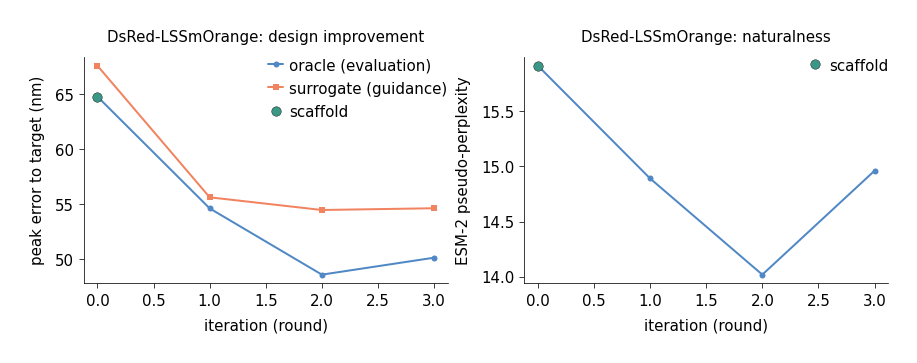

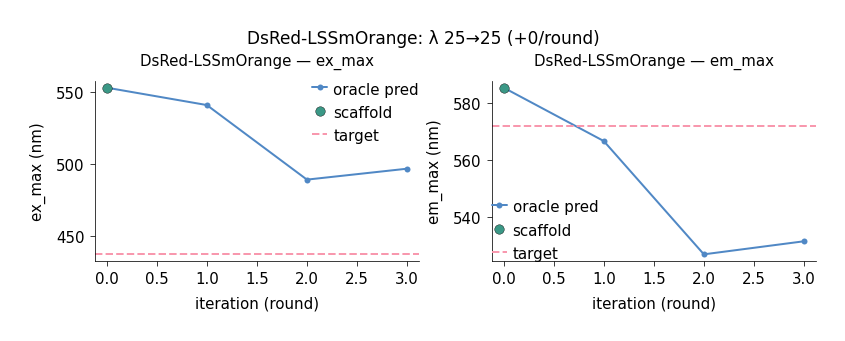

--- DsRed-ZsGreen: DsRed(ex558,em583) -> ZsGreen(ex496,em506) | seq id 41% | peak err 68.3 -> 20.3 nm


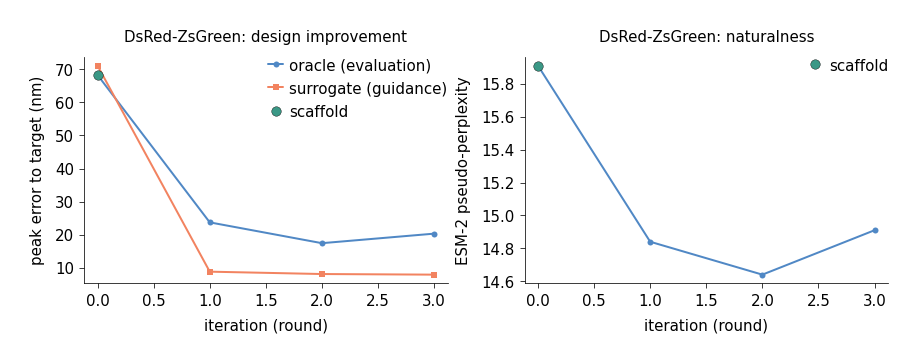

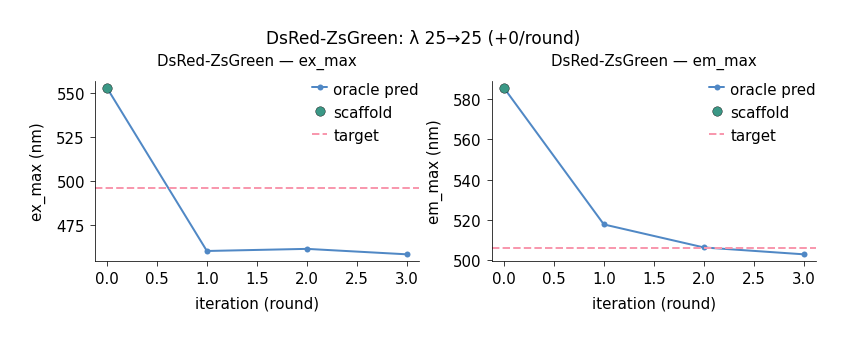

--- DsRed-ZsYellow1: DsRed(ex558,em583) -> ZsYellow1(ex529,em539) | seq id 43% | peak err 35.3 -> 25.1 nm


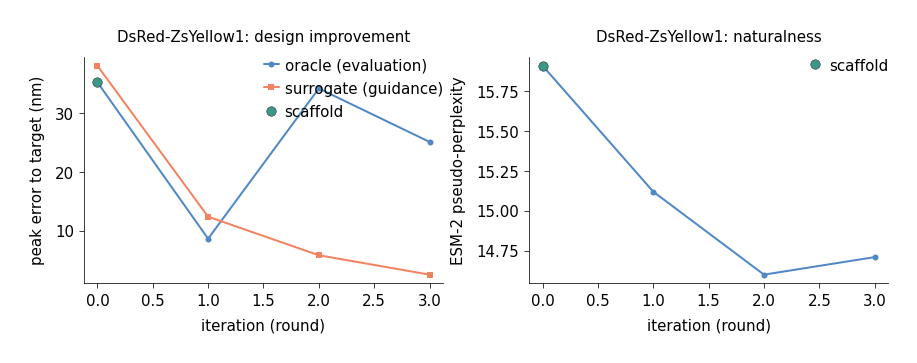

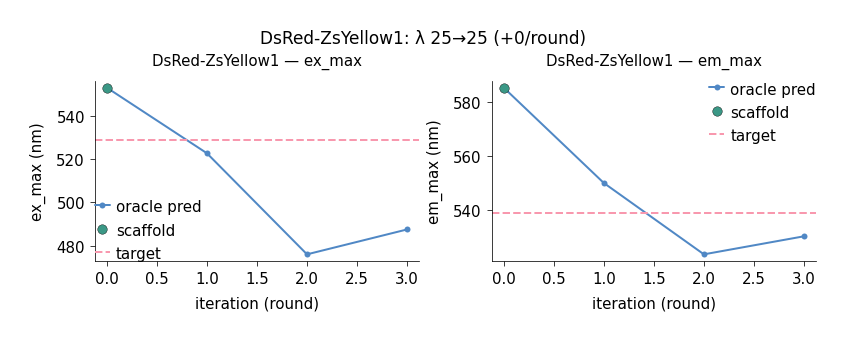

--- DsRed-mRuby: DsRed(ex558,em583) -> mRuby(ex558,em605) | seq id 51% | peak err 12.2 -> 16.9 nm


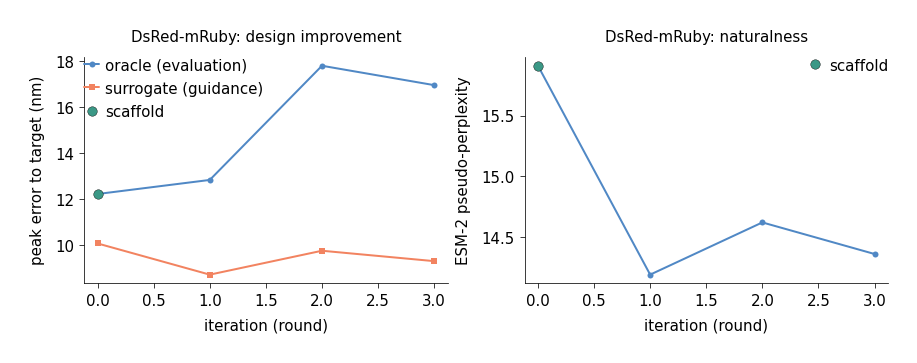

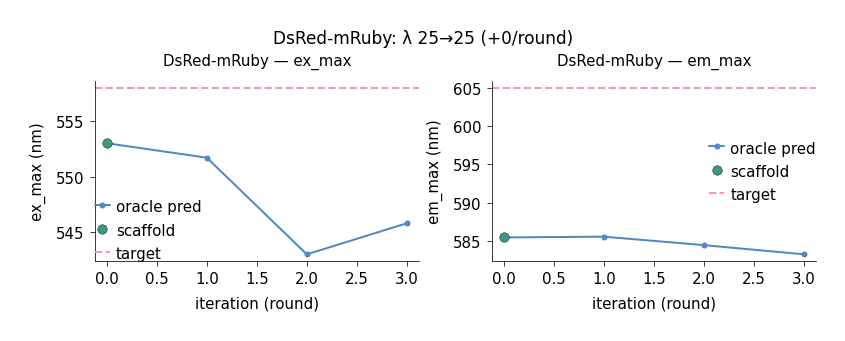

--- avGFP-Sirius: avGFP(ex395,em509) -> Sirius(ex355,em424) | seq id 92% | peak err 73.7 -> 97.1 nm


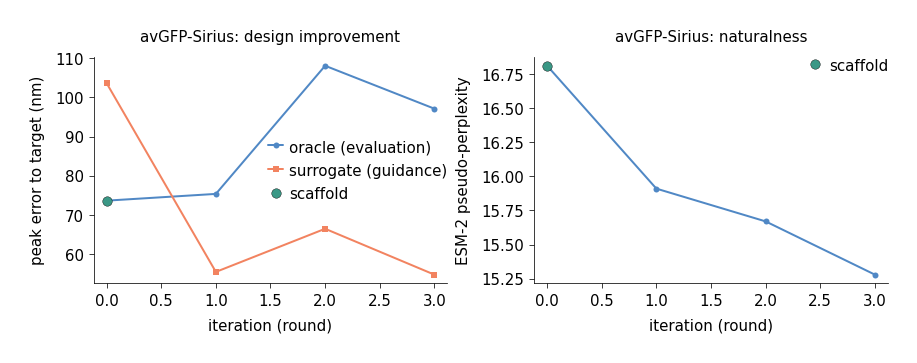

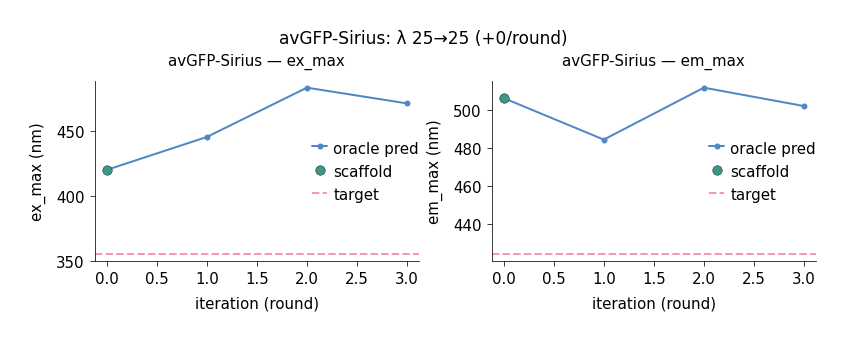

--- avGFP-Sumire: avGFP(ex395,em509) -> Sumire(ex343,em414) | seq id 92% | peak err 84.7 -> 104.7 nm


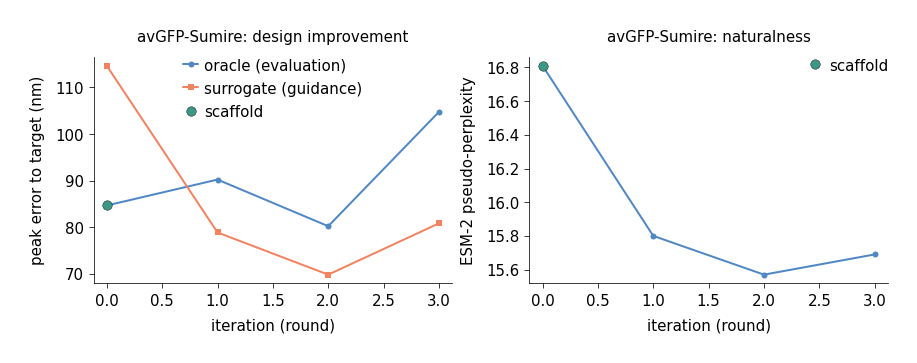

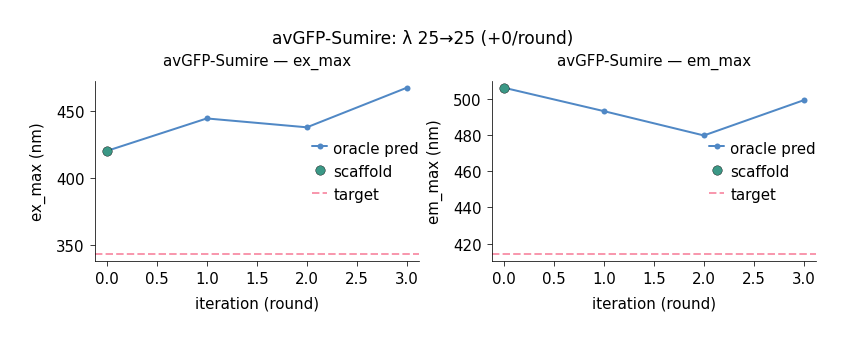

--- avGFP-mAmetrine: avGFP(ex395,em509) -> mAmetrine(ex406,em526) | seq id 89% | peak err 16.7 -> 46.7 nm


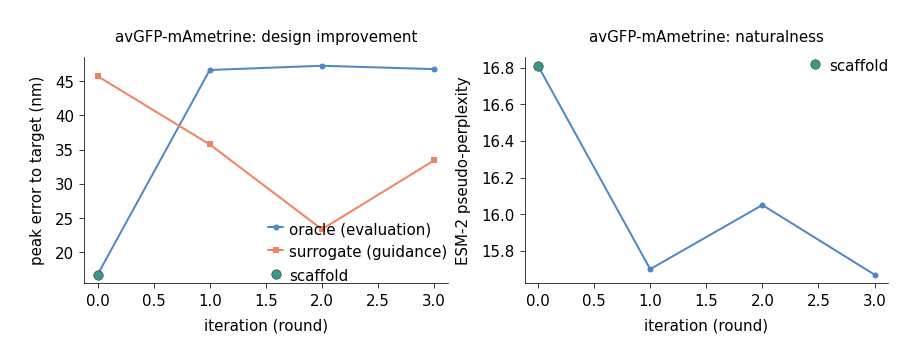

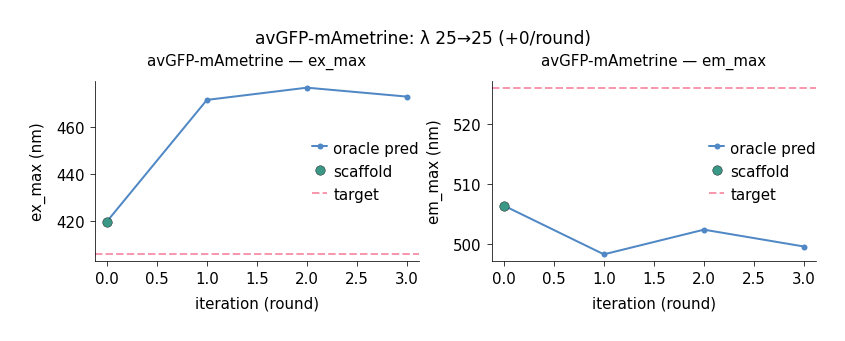

--- avGFP-sREACh2: avGFP(ex395,em509) -> sREACh2(ex519,em531) | seq id 93% | peak err 61.8 -> 13.1 nm


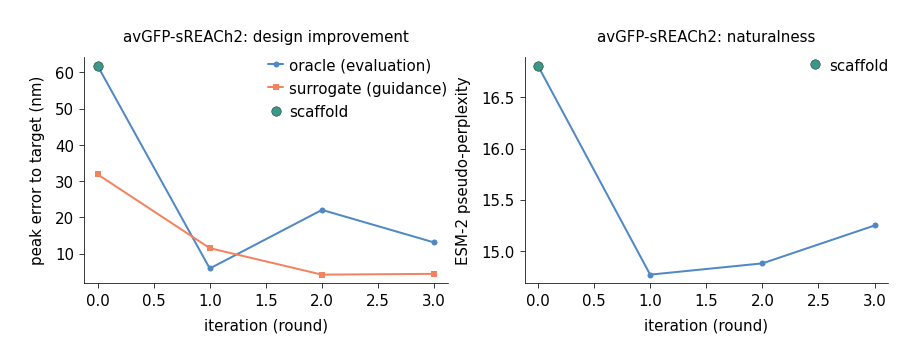

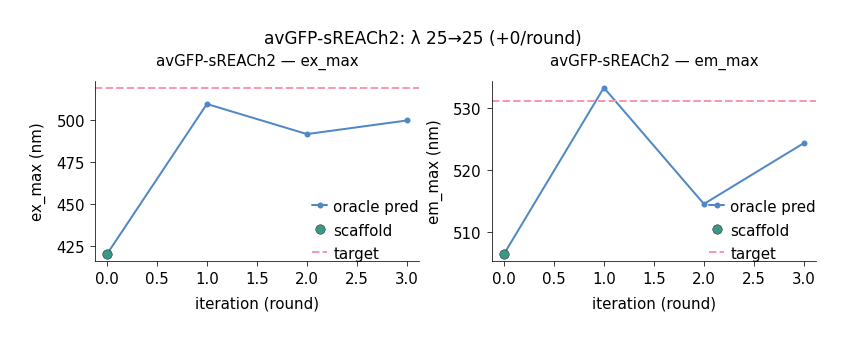

--- eqFP578-LSS-mKate1: eqFP578(ex552,em578) -> LSS-mKate1(ex463,em624) | seq id 88% | peak err 66.9 -> 64.2 nm


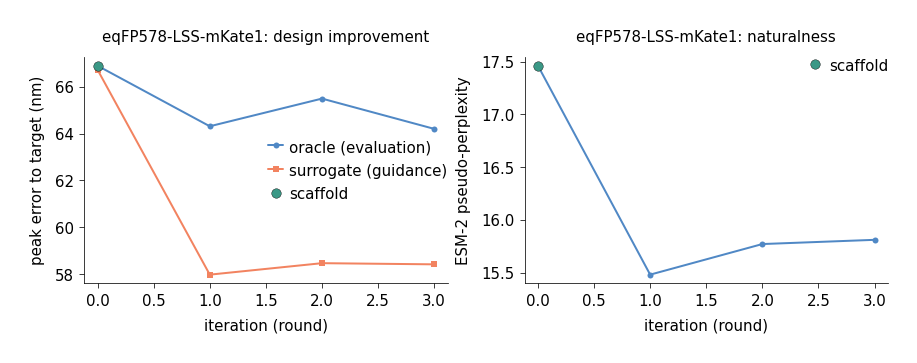

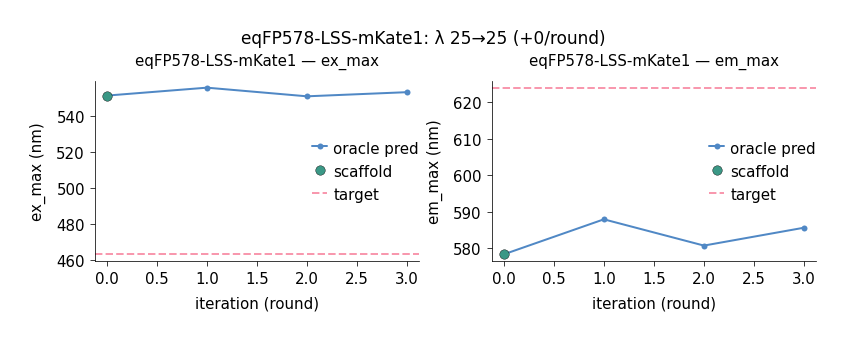

--- eqFP578-LSS-mKate2: eqFP578(ex552,em578) -> LSS-mKate2(ex460,em605) | seq id 88% | peak err 58.9 -> 56.0 nm


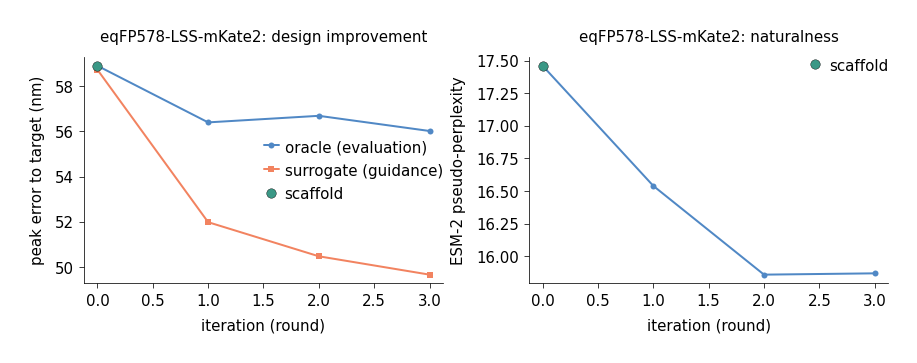

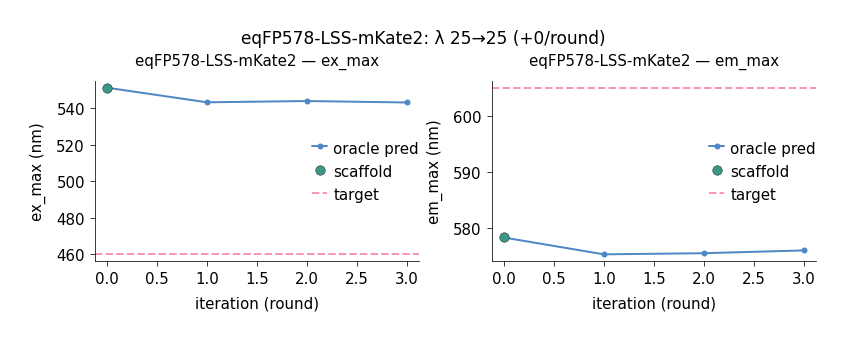

--- eqFP578-mBeRFP: eqFP578(ex552,em578) -> mBeRFP(ex446,em611) | seq id 87% | peak err 68.9 -> 67.0 nm


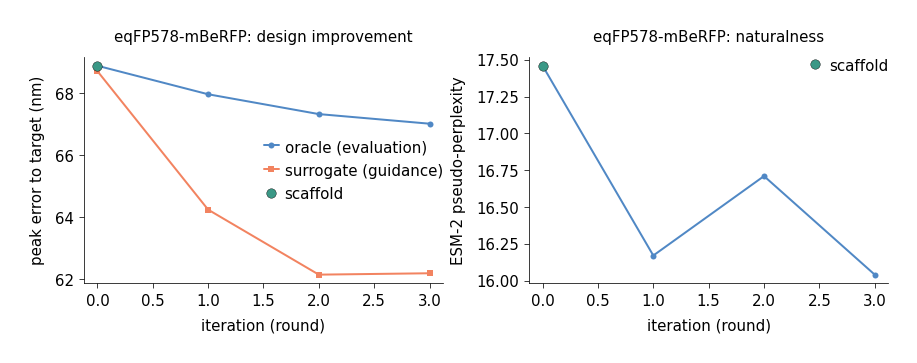

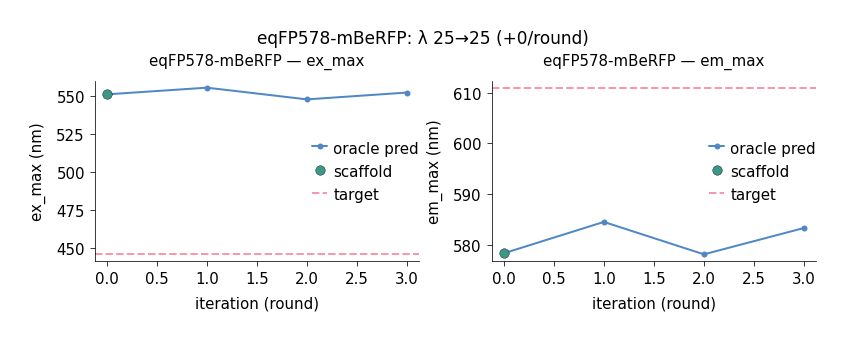

In [6]:
import glob
def show_cycles(files):
    SCAF=apc_c.seaweed
    print(f"{len(files)} example(s):", [os.path.basename(f) for f in files])
    for fn in files:
        H=sorted(list(csv.DictReader(open(fn))), key=lambda h:int(h["round"]))
        name=H[0]["example"]; rr=[int(h["round"]) for h in H]
        tex=float(H[0]["target_ex"]); tem=float(H[0]["target_em"]); tgt=torch.tensor([tex,tem],device=dev)
        print(f"--- {name}: {H[0]['scaffold_name']}(ex{H[0]['scaffold_ex']},em{H[0]['scaffold_em']}) -> {H[0]['target_name']}(ex{tex:.0f},em{tem:.0f}) | seq id {float(H[0]['seq_id_scaf_target']):.0%} | peak err {float(H[0]['peak_err']):.1f} -> {float(H[-1]['peak_err']):.1f} nm")
        if not HAVE_PLT: continue
        orac_err=[float(h["peak_err"]) for h in H]
        surr_err=[float(peak_err_vec(g_peaks(h["designed_seq"]), tgt)[0]) for h in H]
        fig,ax=plt.subplots(1,2,figsize=(12,4.3),constrained_layout=True)
        a=ax[0]
        a.plot(rr,orac_err,marker="o",color=apc_c.aegean,label="oracle (evaluation)")
        a.plot(rr,surr_err,marker="s",color=apc_c.amber,label="surrogate (guidance)")
        a.scatter([0],[orac_err[0]],color=SCAF,s=90,zorder=5,edgecolor="k",linewidth=0.4,label="scaffold")
        a.set_xlabel("iteration (round)"); a.set_ylabel("peak error to target (nm)"); a.set_title(f"{name}: design improvement"); a.legend()
        a=ax[1]; a.plot(rr,[float(h["ppl"]) for h in H],marker="o",color=apc_c.aegean)
        a.scatter([0],[float(H[0]["ppl"])],color=SCAF,s=90,zorder=5,edgecolor="k",linewidth=0.4,label="scaffold")
        a.set_xlabel("iteration (round)"); a.set_ylabel("ESM-2 pseudo-perplexity"); a.set_title(f"{name}: naturalness"); a.legend()
        plt.show()
        # peak trajectories (oracle-predicted) vs target
        fig,axes=plt.subplots(1,2,figsize=(11,4.0),constrained_layout=True)
        for ci,(lab,col,tline) in enumerate([("ex_max","pred_ex",tex),("em_max","pred_em",tem)]):
            a=axes[ci]; vals=[float(h[col]) for h in H]
            a.plot(rr,vals,marker="o",color=apc_c.aegean,label="oracle pred")
            a.scatter([0],[vals[0]],color=SCAF,s=90,zorder=5,edgecolor="k",linewidth=0.4,label="scaffold")
            a.axhline(tline,ls="--",color=apc_c.rose,label="target")
            a.set_xlabel("iteration (round)"); a.set_ylabel(f"{lab} (nm)"); a.set_title(f"{name} \u2014 {lab}"); a.legend()
        fig.suptitle(f"{name}: \u03bb {H[1]['lam_used']}\u2192{H[-1]['lam_used']} (+{int(float(H[2]['lam_used']))-int(float(H[1]['lam_used']))}/round)")
        plt.show()

show_cycles(sorted(glob.glob(os.path.join(OUTDIR,"design_*.csv"))))

## 6. Sequence alignment (per example)

11 per-example triplet alignments (final design)


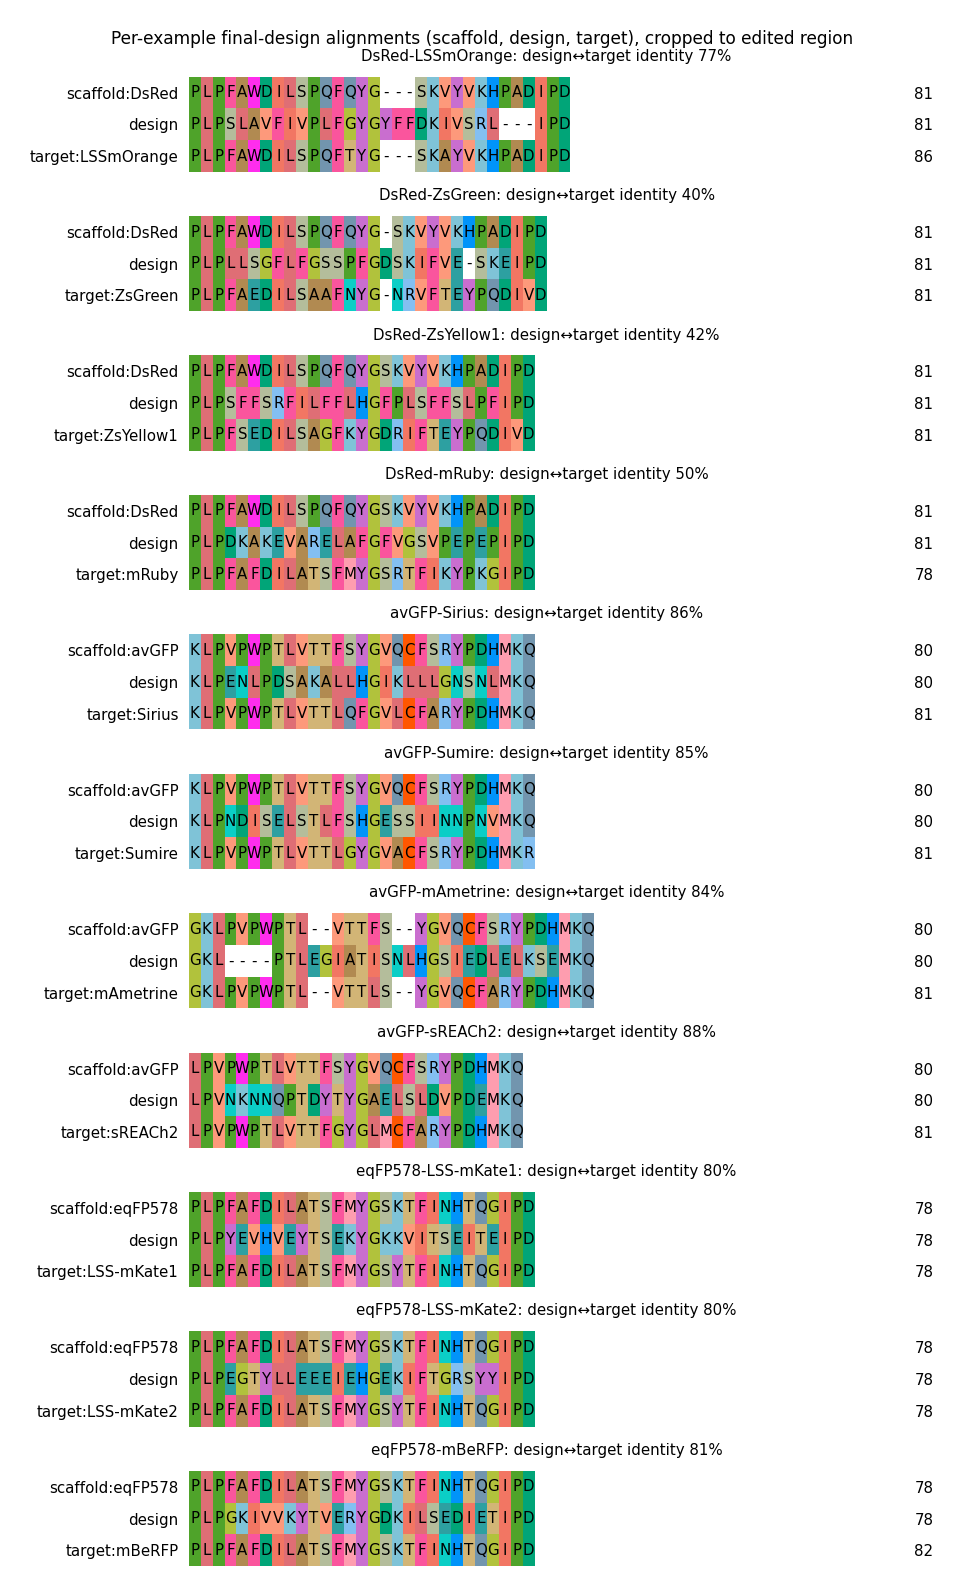

In [7]:
import biotite.sequence as bseq, biotite.sequence.align as balign, biotite.sequence.graphics as bgraphics
MAT=balign.SubstitutionMatrix.std_protein_matrix(); MARGIN=3; SPL=60
def triplet_aln(scaf,des,tgt):
    raw=[scaf,des,tgt]
    aln,_,_,_=balign.align_multiple([bseq.ProteinSequence(s) for s in raw], MAT, gap_penalty=(-10,-1))
    tr=aln.trace; sym=lambda k,c:(raw[k][tr[c,k]] if tr[c,k]>=0 else "-")
    both=[c for c in range(tr.shape[0]) if tr[c,1]>=0 and tr[c,2]>=0]
    id_dt=(sum(sym(1,c)==sym(2,c) for c in both)/len(both)) if both else 0.0
    diff=[c for c in range(tr.shape[0]) if sym(0,c)!=sym(1,c)]
    lo,hi=(max(0,min(diff)-MARGIN), min(tr.shape[0],max(diff)+MARGIN+1)) if diff else (0,tr.shape[0])
    return aln[lo:hi], id_dt
def show_align(files):
    print(f"{len(files)} per-example triplet alignments (final design)")
    if HAVE_PLT and files:
        fig,axes=plt.subplots(len(files),1,figsize=(13,2*len(files))); axes=np.atleast_1d(axes)
        for r,fn in enumerate(files):
            H=sorted(list(csv.DictReader(open(fn))),key=lambda h:int(h["round"])); d=H[-1]
            labels=[f"scaffold:{d['scaffold_name']}", "design", f"target:{d['target_name']}"]
            sub,id_dt=triplet_aln(d["scaffold_seq"],d["designed_seq"],d["target_seq"])
            bgraphics.plot_alignment_type_based(axes[r], sub, labels=labels, symbols_per_line=SPL, show_numbers=True)
            axes[r].set_title(f"{d['example']}: design\u2194target identity {id_dt:.0%}")
        plt.suptitle("Per-example final-design alignments (scaffold, design, target), cropped to edited region")
        plt.tight_layout(); plt.show()

show_align(sorted(glob.glob(os.path.join(OUTDIR,"design_*.csv"))))

## 8. Best design across iterations (loaded from CSV)

For each example we pick the **round with the lowest oracle peak error** (round ≥1; round 0 = scaffold
baseline) and show that single best design vs the target: an ex_max / em_max bar comparison (scaffold,
design as judged by oracle and surrogate, target) plus a summary table.

############ chromophore-anchored designs (active PHASE_PLAN / OUTDIR) ############


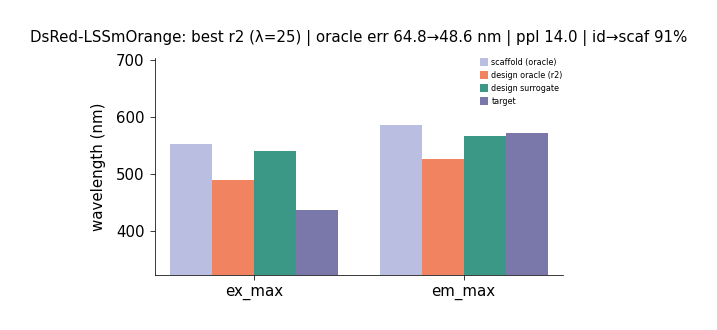

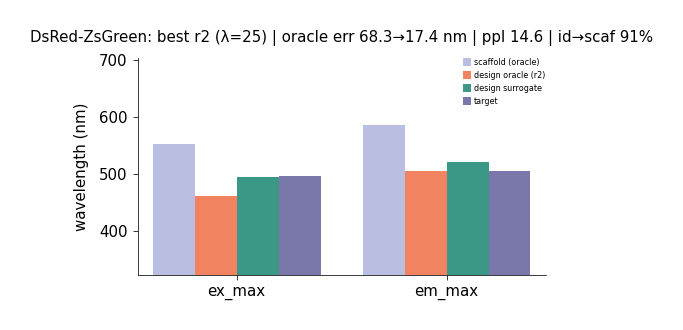

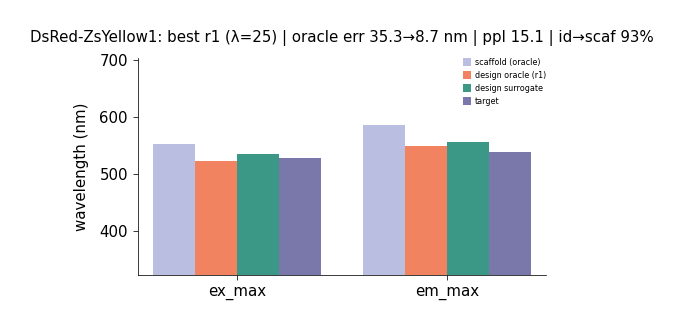

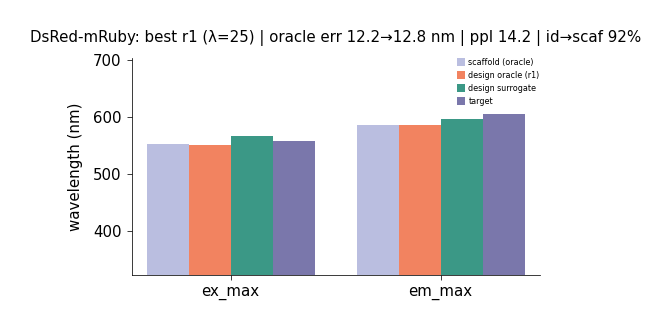

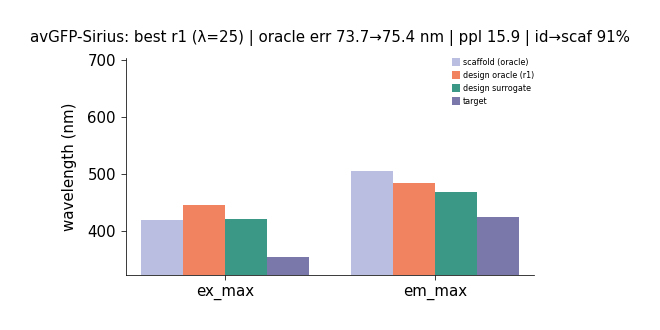

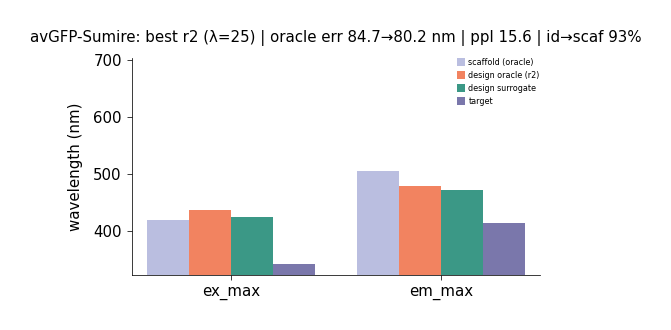

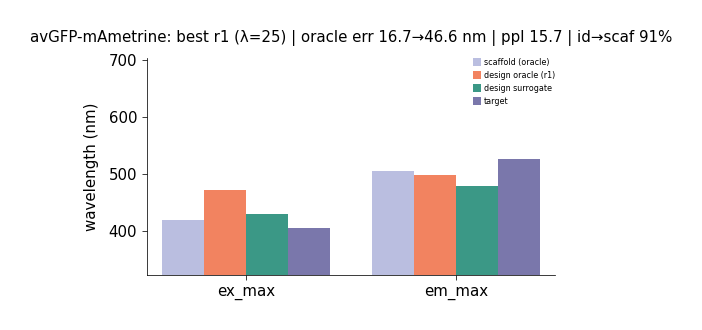

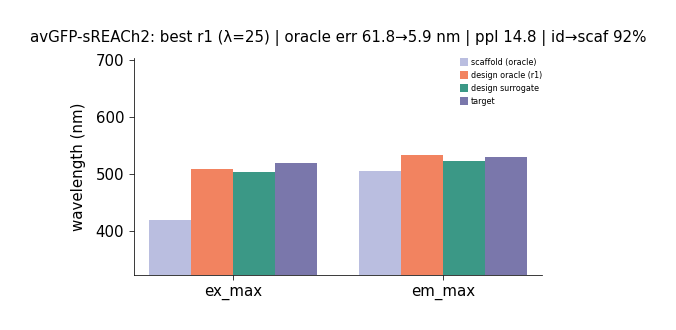

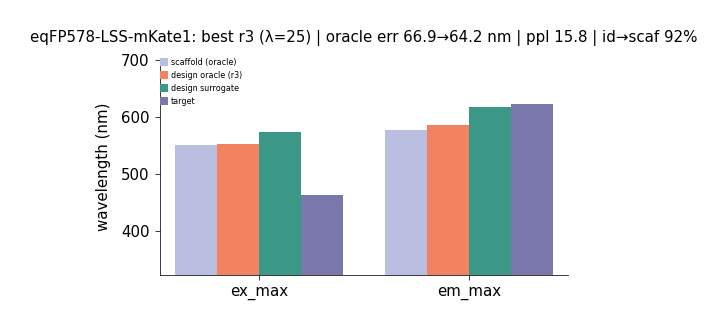

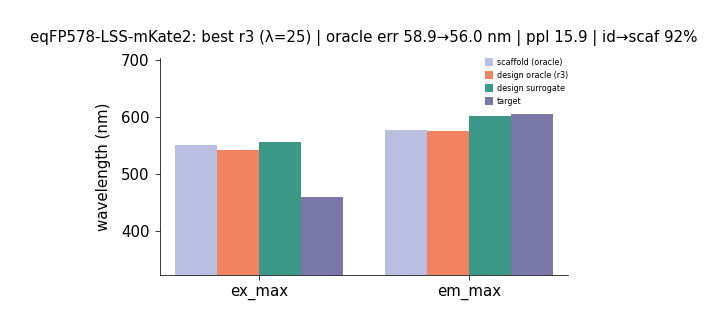

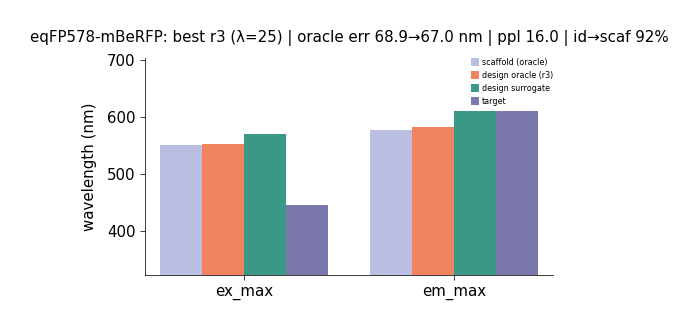


=== best design per example (DsRed/avGFP/eqFP578 -> named targets) ===
example                    seq id scaf err best r   λ orac err surr err    Δerr   ppl  id->scaf
DsRed-LSSmOrange             80%     64.8      2  25     48.6     54.5   -16.2  14.0      91%
DsRed-ZsGreen                41%     68.3      2  25     17.4      8.1   -50.8  14.6      91%
DsRed-ZsYellow1              43%     35.3      1  25      8.7     12.4   -26.6  15.1      93%
DsRed-mRuby                  51%     12.2      1  25     12.8      8.7    +0.6  14.2      92%
avGFP-Sirius                 92%     73.7      1  25     75.4     55.5    +1.7  15.9      91%
avGFP-Sumire                 92%     84.7      2  25     80.2     69.8    -4.4  15.6      93%
avGFP-mAmetrine              89%     16.7      1  25     46.6     35.7   +29.9  15.7      91%
avGFP-sREACh2                93%     61.8      1  25      5.9     11.5   -55.9  14.8      92%
eqFP578-LSS-mKate1           88%     66.9      3  25     64.2     58.4    -2.7  

In [8]:
def show_best(files, group):
    rowsum=[]
    for fn in files:
        H=sorted(list(csv.DictReader(open(fn))), key=lambda h:int(h["round"]))
        scaf=H[0]; gen=[h for h in H if int(h["round"])>=1]
        best=min(gen, key=lambda h:float(h["peak_err"]))
        name=best["example"]; tex=float(scaf["target_ex"]); tem=float(scaf["target_em"]); tgt=torch.tensor([tex,tem],device=dev)
        b_orac=oracle_peaks(best["designed_seq"])[0].cpu().numpy(); b_surr=g_peaks(best["designed_seq"])[0].cpu().numpy()
        b_surr_err=float(0.5*(abs(b_surr[0]-tex)+abs(b_surr[1]-tem)))
        s_orac=oracle_peaks(scaf["designed_seq"])[0].cpu().numpy()
        rowsum.append((name,float(scaf["seq_id_scaf_target"]),float(scaf["peak_err"]),int(best["round"]),
                       int(float(best["lam_used"])),float(best["peak_err"]),b_surr_err,float(best["ppl"]),float(best["ident_to_scaffold"])))
        if not HAVE_PLT: continue
        fig,ax=plt.subplots(figsize=(7,4.2)); x=np.arange(2); w=0.2
        ax.bar(x-1.5*w,[s_orac[0],s_orac[1]],w,color=apc_c.wish,label="scaffold (oracle)")
        ax.bar(x-0.5*w,[b_orac[0],b_orac[1]],w,color=apc_c.amber,label=f"design oracle (r{best['round']})")
        ax.bar(x+0.5*w,[b_surr[0],b_surr[1]],w,color=apc_c.seaweed,label="design surrogate")
        ax.bar(x+1.5*w,[tex,tem],w,color=apc_c.aster,label="target")
        ax.set_xticks(x); ax.set_xticklabels(["ex_max","em_max"]); ax.set_ylabel("wavelength (nm)")
        ax.set_ylim(min(EXM.min(),EMM.min())-20, max(EXM.max(),EMM.max())+20); ax.legend(fontsize=8)
        ax.set_title(f"{name}: best r{best['round']} (\u03bb={int(float(best['lam_used']))}) | oracle err {float(scaf['peak_err']):.1f}\u2192{float(best['peak_err']):.1f} nm | ppl {float(best['ppl']):.1f} | id\u2192scaf {float(best['ident_to_scaffold']):.0%}")
        plt.tight_layout(); plt.show()
    print(f"\n=== best design per example ({group}) ===")
    print(f"{'example':<26}{'seq id':>7}{'scaf err':>9}{'best r':>7}{'λ':>4}{'orac err':>9}{'surr err':>9}{'Δerr':>8}{'ppl':>6}{'id->scaf':>10}")
    for name,sid,serr,br,lam,berr,bserr,ppl,idsc in rowsum:
        print(f"{name:<26}{sid:>6.0%}{serr:>9.1f}{br:>7d}{lam:>4d}{berr:>9.1f}{bserr:>9.1f}{berr-serr:>+8.1f}{ppl:>6.1f}{idsc:>9.0%}")
    return rowsum

files=sorted(glob.glob(os.path.join(OUTDIR,"design_*.csv")))
print("############ chromophore-anchored designs (active PHASE_PLAN / OUTDIR) ############")
_=show_best(files,"DsRed/avGFP/eqFP578 -> named targets")